In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import json
import os
from tqdm import tqdm
import math
from PIL import Image
import random

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [29]:
# 自定義資料集
class MiniImageNetDataset(Dataset):
    def __init__(self, txt_file, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        
        # 讀取txt檔案中的路徑和標籤
        with open(txt_file, 'r') as f:
            for line in f:
                img_path, label = line.strip().split()
                self.data.append((img_path, int(label)))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        # 設定完整路徑 - 這裡修正路徑
        full_path = os.path.join(self.root_dir, img_path)
        
        # 讀取原始圖片
        img = Image.open(full_path).convert('RGB')
        
        # 根據需要進行不同通道的處理
        if self.transform:
            img = self.transform(img)
            
        return img, label

In [30]:
# 修改RandomChannelSelect類只使用填零方法
class RandomChannelSelect(object):
    """隨機選擇保留哪些通道，並將其他通道設為0"""
    def __init__(self, p_one=1/3, p_two=1/3, p_three=1/3):
        # 確保概率和為1
        total_p = p_one + p_two + p_three
        self.p_one = p_one / total_p
        self.p_two = p_two / total_p
        self.p_three = p_three / total_p
    
    def __call__(self, img):
        # 確保輸入是RGB圖像
        if img.size(0) != 3:
            raise ValueError(f"期望3通道圖像，得到{img.size(0)}通道")
        
        # 決定保留多少通道
        rand_val = random.random()
        
        if rand_val < self.p_one:  # 選擇單通道
            # 隨機選擇一個通道
            channel_idx = random.randint(0, 2)
            mask = torch.zeros_like(img)
            mask[channel_idx] = 1.0
            return img * mask
        
        elif rand_val < self.p_one + self.p_two:  # 選擇雙通道
            # 隨機選擇兩個通道
            remove_idx = random.randint(0, 2)
            mask = torch.ones_like(img)
            mask[remove_idx] = 0.0
            return img * mask
        
        else:  # 選擇全部通道
            # 返回原始RGB圖像
            return img

* 普通卷積網路，作為基礎比較依據

In [6]:
class StandardCNN(nn.Module):
    def __init__(self, num_classes=100, input_channels=3):
        super().__init__()
        
        # 根據輸入通道數修改第一層
        self.features = nn.Sequential(
            # 第一層卷積 (input_channels -> 64 通道)
            nn.Conv2d(input_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 84x84 -> 42x42
            
            # 其餘層不變
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 42x42 -> 21x21
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 21x21 -> 10x10
        )
        
        # 分類頭不變
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

* 動態卷積網路，這次主要的模型

In [39]:
class DynamicConvNetwork(nn.Module):
    def __init__(self, num_classes=100, K=8, embed_dim=64):
        super().__init__()
        
        # 第一層直接使用靜態卷積（或動態卷積）將3通道轉換為embed_dim通道
        self.first_conv = nn.Conv2d(3, embed_dim, kernel_size=3, padding=1)
        
   
        self.dynamic_conv1 = self._make_dynamic_conv_layer(embed_dim, 64, K)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.dynamic_conv2 = self._make_dynamic_conv_layer(64, 128, K)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.dynamic_conv3 = self._make_dynamic_conv_layer(128, 256, K)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # 分類頭
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )
        
    def _make_dynamic_conv_layer(self, in_channels, out_channels, K):
        # 建立一個容器來放置所有模組和參數
        layer = nn.Module()
        
        # 注意力機制
        layer.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, 64, 1),
            nn.ReLU(),
            nn.Conv2d(64, K, 1),
            nn.Softmax(dim=1)
        )
        
        # 卷積權重和偏置
        layer.weight_tensors = nn.ParameterList([
            nn.Parameter(torch.Tensor(out_channels, in_channels, 3, 3)) 
            for _ in range(K)
        ])
        
        # 初始化權重
        for weight in layer.weight_tensors:
            nn.init.kaiming_uniform_(weight, a=math.sqrt(5))
            
        layer.bias = nn.Parameter(torch.zeros(out_channels))
        
        # 批次歸一化和激活
        layer.bn = nn.BatchNorm2d(out_channels)
        layer.relu = nn.ReLU(inplace=True)
        
        return layer
    
    def _apply_dynamic_conv(self, x, layer):
        batch_size = x.size(0)
        
        # 計算注意力權重
        attn = layer.attention(x)  # [B, K, 1, 1]
        
        # 對於每個樣本執行卷積
        out = torch.zeros(batch_size, layer.weight_tensors[0].size(0), 
                         x.size(2), x.size(3), device=x.device)
        
        for b in range(batch_size):
            # 組合卷積核權重
            kernel_weight = 0
            for k in range(len(layer.weight_tensors)):
                kernel_weight += attn[b, k, 0, 0] * layer.weight_tensors[k]
                
            # 執行卷積
            out[b] = F.conv2d(x[b:b+1], kernel_weight, layer.bias, padding=1)
        
        # 批正規化和激活
        out = layer.bn(out)
        out = layer.relu(out)
        
        return out
    
    def forward(self, x):
        
        # 通道嵌入
        x = self.first_conv(x)
        
        
        x = self._apply_dynamic_conv(x, self.dynamic_conv1)
        x = self.pool1(x)
        
        x = self._apply_dynamic_conv(x, self.dynamic_conv2)
        x = self.pool2(x)
        
        x = self._apply_dynamic_conv(x, self.dynamic_conv3)
        x = self.pool3(x)
        

        x = self.classifier(x)
        
        return x

In [32]:
# 修改回標準訓練函數
def train_with_channel_dropout(model, loader, criterion, optimizer, device, channel_dropout=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        # 清零梯度
        optimizer.zero_grad()
        
        # 前向傳播
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向傳播和優化
        loss.backward()
        optimizer.step()
        
        # 統計
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    
    # 更新漸進式通道丟棄策略
    if channel_dropout is not None:
        channel_dropout.step()
    
    return epoch_loss, epoch_acc

# 驗證/測試函數
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            
            # 前向傳播
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # 統計
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

In [33]:
# 完整訓練流程
def train_model(model_name, model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=30, save_dir='./checkpoints'):
    """
    訓練模型並保存最佳權重
    
    參數:
        model_name: 模型名稱，用於保存檔案
        model: 要訓練的模型
        train_loader: 訓練數據加載器
        val_loader: 驗證數據加載器
        criterion: 損失函數
        optimizer: 優化器
        scheduler: 學習率調度器
        device: 設備(cuda或cpu)
        num_epochs: 訓練周期數
        save_dir: 保存檢查點的目錄
    """
    os.makedirs(save_dir, exist_ok=True)
    
    best_val_acc = 0.0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    # 獲取訓練加載器中的漸進式通道丟棄策略
    channel_dropout = None
    if hasattr(train_loader.dataset.transform.transforms[-1], 'step'):
        channel_dropout = train_loader.dataset.transform.transforms[-1]
    
    print(f"開始訓練 {model_name} 在 {device}...")
    
    for epoch in range(num_epochs):
        # 訓練階段
        train_loss, train_acc = train_with_channel_dropout(
            model, train_loader, criterion, optimizer, device, channel_dropout
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # 驗證階段
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # 學習率調整
        scheduler.step(val_acc)
        
        # 保存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model_save_path = os.path.join(save_dir, f"best_{model_name}.pth")
            torch.save(model.state_dict(), model_save_path)
            print(f"保存最佳模型到 {model_save_path}")
        
        print(f"周期 {epoch+1}/{num_epochs}, "
              f"訓練損失: {train_loss:.4f}, 訓練準確率: {train_acc:.4f}, "
              f"驗證損失: {val_loss:.4f}, 驗證準確率: {val_acc:.4f}")
    
    print(f"{model_name} 訓練完成!")
    
    # 繪製訓練過程圖表
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Validation')
    plt.title(f'{model_name} Loss vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train')
    plt.plot(val_accs, label='Validation')
    plt.title(f'{model_name} Accuracy vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'{model_name}_training_curves.png'))
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc
    }

In [34]:
# RGB
rgb_transform = transforms.Compose([
    transforms.RandomResizedCrop(84),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# RG
rg_transform = transforms.Compose([
    transforms.RandomResizedCrop(84),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    lambda x: x[0:2]  # 只保留R和G通道(前两个通道)
])

# G
g_transform = transforms.Compose([
    transforms.RandomResizedCrop(84),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    lambda x: x[1:2]  # 只保留G通道(第二个通道)
])

# 動態模型的數據轉換 - 保留隨機通道選擇
dynamic_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(84),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    RandomChannelSelect(p_one=1/3, p_two=1/3, p_three=1/3)
])



batch_size = 32

# 修正資料夾路徑
root_dir = 'dataset'  # 基於HW1下的dataset資料夾
txt_dir = 'dataset'   # txt檔案所在資料夾

# 創建各模型的數據集
rgb_train_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'train.txt'),
    root_dir=root_dir,
    transform=rgb_transform
)

rg_train_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'train.txt'),
    root_dir=root_dir,
    transform=rg_transform
)

g_train_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'train.txt'),
    root_dir=root_dir,
    transform=g_transform
)

dynamic_train_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'train.txt'),
    root_dir=root_dir,
    transform=dynamic_train_transform  
)

# 數據加載器
rgb_train_loader = DataLoader(rgb_train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
rg_train_loader = DataLoader(rg_train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
g_train_loader = DataLoader(g_train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
dynamic_train_loader = DataLoader(dynamic_train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

# 创建验证数据集和加载器
val_transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(84),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# RG
rg_val_transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(84),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    lambda x: x[0:2]  # 只保留R和G通道
])

# G
g_val_transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(84),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    lambda x: x[1:2]  # 只保留G通道
])


# 创建验证集
rgb_val_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'val.txt'),
    root_dir=root_dir,
    transform=val_transform
)

rg_val_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'val.txt'),
    root_dir=root_dir,
    transform=rg_val_transform
)

g_val_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'val.txt'),
    root_dir=root_dir,
    transform=g_val_transform
)

dynamic_val_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'val.txt'),
    root_dir=root_dir,
    transform=val_transform
)

# 创建验证数据加载器
rgb_val_loader = DataLoader(rgb_val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
rg_val_loader = DataLoader(rg_val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
g_val_loader = DataLoader(g_val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
dynamic_val_loader = DataLoader(dynamic_val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [35]:
class ChannelSelectDataset(Dataset):

    def __init__(self, dataset, channels='RGB', output_channels=None):

        self.dataset = dataset
        self.channel_map = {
            'RGB': [0, 1, 2],  # 所有通道
            'R': [0],          # 只有红色通道
            'G': [1],          # 只有绿色通道
            'B': [2],          # 只有蓝色通道
            'RG': [0, 1],      # 红色和绿色通道
            'GB': [1, 2],      # 绿色和蓝色通道
            'RB': [0, 2]       # 红色和蓝色通道
        }
        
        if channels not in self.channel_map:
            raise ValueError(f"無效的通道組合: {channels}")
        
        self.active_channels = self.channel_map[channels]
        
        # 如果没有指定output_channels，则使用选择的通道数
        self.output_channels = output_channels if output_channels is not None else len(self.active_channels)
    
    def __getitem__(self, idx):
        # 获取原始样本
        img, label = self.dataset[idx]
        
        if self.output_channels == 3:
            # 创建一个全零的3通道张量 (适用于DynamicConvNetwork)
            selected_img = torch.zeros_like(img)
            # 只填充选择的通道
            for ch in self.active_channels:
                selected_img[ch] = img[ch]
            return selected_img, label
        
        elif self.output_channels == len(self.active_channels):
            # 直接返回选择的通道 (适用于RG_CNN和G_CNN)
            return img[self.active_channels], label
            
        else:
            raise ValueError(f"要求输出{self.output_channels}通道，但選擇了{len(self.active_channels)}個通道")
    
    def __len__(self):
        return len(self.dataset)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


rgb_model = StandardCNN(num_classes=100, input_channels=3).to(device)
rg_model = StandardCNN(num_classes=100, input_channels=2).to(device)
g_model = StandardCNN(num_classes=100, input_channels=1).to(device)


criterion = nn.CrossEntropyLoss()

# RGB模型
rgb_optimizer = optim.Adam(rgb_model.parameters(), lr=0.001)
rgb_scheduler = optim.lr_scheduler.ReduceLROnPlateau(rgb_optimizer, mode='max', factor=0.5, patience=5)

rgb_results = train_model(
    "RGB_CNN", 
    rgb_model, 
    rgb_train_loader, 
    rgb_val_loader,  
    criterion, 
    rgb_optimizer, 
    rgb_scheduler, 
    device, 
    num_epochs=30,
    save_dir='./checkpoints'
)

# RG模型
rg_optimizer = optim.Adam(rg_model.parameters(), lr=0.001)
rg_scheduler = optim.lr_scheduler.ReduceLROnPlateau(rg_optimizer, mode='max', factor=0.5, patience=5)

rg_results = train_model(
    "RG_CNN", 
    rg_model, 
    rg_train_loader, 
    rg_val_loader,
    criterion, 
    rg_optimizer, 
    rg_scheduler, 
    device, 
    num_epochs=30,
    save_dir='./checkpoints'
)

# G模型
g_optimizer = optim.Adam(g_model.parameters(), lr=0.001)
g_scheduler = optim.lr_scheduler.ReduceLROnPlateau(g_optimizer, mode='max', factor=0.5, patience=5)

g_results = train_model(
    "G_CNN", 
    g_model, 
    g_train_loader, 
    g_val_loader,
    criterion, 
    g_optimizer, 
    g_scheduler, 
    device, 
    num_epochs=30,
    save_dir='./checkpoints'
)

開始訓練 DynamicConvNetwork_8k 在 cuda...


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 15.45it/s]


保存最佳模型到 ./checkpoints/best_DynamicConvNetwork_8k.pth
周期 1/30, 訓練損失: 3.6730, 訓練準確率: 0.0716, 驗證損失: 3.2960, 驗證準確率: 0.1133


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 15.05it/s]


保存最佳模型到 ./checkpoints/best_DynamicConvNetwork_8k.pth
周期 2/30, 訓練損失: 3.3883, 訓練準確率: 0.1207, 驗證損失: 2.9682, 驗證準確率: 0.1911


...

周期 28/30, 訓練損失: 1.9362, 訓練準確率: 0.4518, 驗證損失: 1.4884, 驗證準確率: 0.5600


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 16.22it/s]


周期 29/30, 訓練損失: 1.9189, 訓練準確率: 0.4582, 驗證損失: 1.4642, 驗證準確率: 0.5667


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 17.07it/s]


周期 30/30, 訓練損失: 1.8967, 訓練準確率: 0.4632, 驗證損失: 1.4314, 驗證準確率: 0.5778
DynamicConvNetwork_8k 訓練完成!


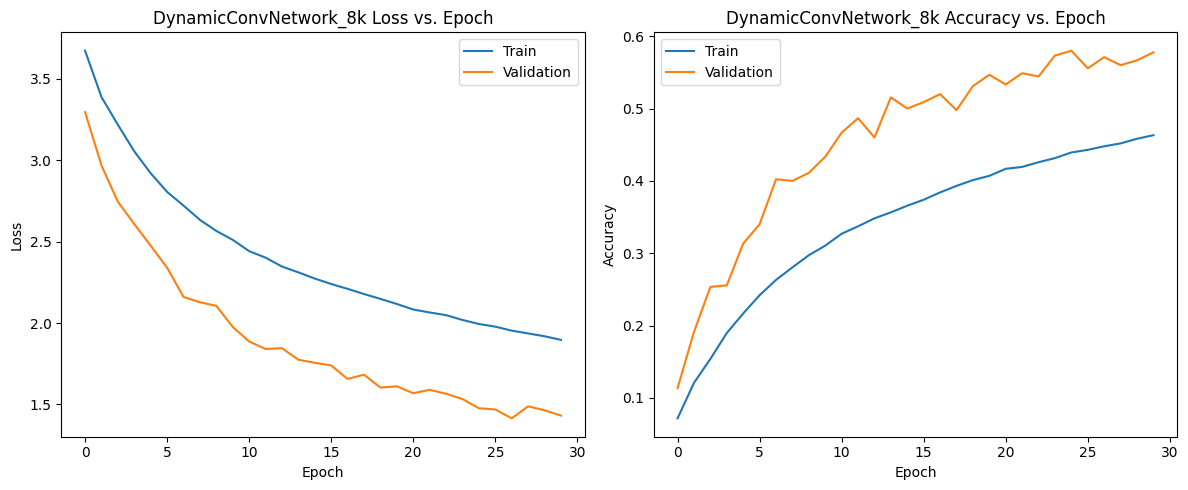

In [40]:
# 設置設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 實例化 DynamicConvNetwork 模型
dynamic_model = DynamicConvNetwork(num_classes=100).to(device)

# 定義損失函數和優化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dynamic_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# 訓練 DynamicConvNetwork 模型
dynamic_results = train_model(
    "DynamicConvNetwork_8k", 
    dynamic_model, 
    dynamic_train_loader, 
    dynamic_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device, 
    num_epochs=30,
    save_dir='./checkpoints'
)


---

In [11]:
def compare_model_parameters(rgb_model, rg_model, g_model, dynamic_model):
    """比較多個標準模型與動態卷積模型的參數量"""
    # 計算各個模型的參數量
    rgb_params = sum(p.numel() for p in rgb_model.parameters())
    rg_params = sum(p.numel() for p in rg_model.parameters())
    g_params = sum(p.numel() for p in g_model.parameters())
    dynamic_params = sum(p.numel() for p in dynamic_model.parameters())
    
    # 計算標準模型參數總量
    total_standard_params = (rgb_params + rg_params + g_params)*3
    
    # 計算節省的參數量
    param_reduction = (total_standard_params - dynamic_params) / total_standard_params * 100
    
    print(f"RGB模型參數量: {rgb_params:,}")
    print(f"RG模型參數量: {rg_params:,}")
    print(f"G模型參數量: {g_params:,}")
    print(f"標準模型總參數量: {total_standard_params:,}")
    print(f"動態卷積模型參數量: {dynamic_params:,}")
    print(f"參數減少: {param_reduction:.2f}%")
    
    return {
        "rgb_params": rgb_params,
        "rg_params": rg_params,
        "g_params": g_params,
        "total_standard_params": total_standard_params,
        "dynamic_params": dynamic_params,
        "param_reduction": param_reduction
    }

In [19]:
param_comparison = compare_model_parameters(rgb_model, rg_model, g_model, dynamic_model)


print(f"動態模型比標準模型總共節省了 {param_comparison['param_reduction']:.2f}% 的参數")

RGB模型參數量: 397,412
RG模型參數量: 396,836
G模型參數量: 396,260
標準模型總參數量: 3,571,524
動態卷積模型參數量: 1,668,208
參數減少: 53.29%
動態模型比標準模型總共節省了 53.29% 的参數


---

In [2]:
def display_model_accuracies(models, data_loaders, criterion, device):

    print("\n" + "="*50)
    print("模型準確率統計")
    print("="*50)
    
    for model_name, model in models.items():
        print(f"\n{model_name}模型評估結果:")
        print("-"*40)
        
        # 确保模型在评估模式
        model.eval()
        
        # 使用训练数据评估
        if model_name in data_loaders and 'train' in data_loaders[model_name]:
            train_loader = data_loaders[model_name]['train']
            train_loss, train_acc = evaluate(model, train_loader, criterion, device)
            print(f"訓練集 - 損失: {train_loss:.4f}, 準確率: {train_acc:.4f} ({train_acc*100:.2f}%)")
        
        # 使用验证数据评估
        if model_name in data_loaders and 'val' in data_loaders[model_name]:
            val_loader = data_loaders[model_name]['val']
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)
            print(f"驗證集 - 損失: {val_loss:.4f}, 準確率: {val_acc:.4f} ({val_acc*100:.2f}%)")
    
    print("\n" + "="*50)

In [12]:
# 設定設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用設備: {device}")

# 重新初始化模型
print("正在初始化模型...")
rgb_model = StandardCNN(num_classes=100, input_channels=3).to(device)
rg_model = StandardCNN(num_classes=100, input_channels=2).to(device)
g_model = StandardCNN(num_classes=100, input_channels=1).to(device)
dynamic_model = DynamicConvNetwork(num_classes=100).to(device)

# 從檢查點載入模型權重（如果有的話）
try:
    print("嘗試載入已訓練的模型權重...")
    rgb_model.load_state_dict(torch.load('./checkpoints/best_RGB_CNN.pth'))
    print("RGB_CNN 模型權重載入成功！")
except Exception as e:
    print(f"無法載入 RGB_CNN 模型權重: {e}")
    print("使用未訓練的 RGB_CNN 模型")

try:
    rg_model.load_state_dict(torch.load('./checkpoints/best_RG_CNN.pth'))
    print("RG_CNN 模型權重載入成功！")
except Exception as e:
    print(f"無法載入 RG_CNN 模型權重: {e}")
    print("使用未訓練的 RG_CNN 模型")

try:
    g_model.load_state_dict(torch.load('./checkpoints/best_G_CNN.pth'))
    print("G_CNN 模型權重載入成功！")
except Exception as e:
    print(f"無法載入 G_CNN 模型權重: {e}")
    print("使用未訓練的 G_CNN 模型")

try:
    dynamic_model.load_state_dict(torch.load('./checkpoints/best_DynamicConvNetwork.pth'))
    print("DynamicConvNetwork 模型權重載入成功！")
except Exception as e:
    print(f"無法載入 DynamicConvNetwork 模型權重: {e}")
    print("使用未訓練的 DynamicConvNetwork 模型")

使用設備: cuda
正在初始化模型...
嘗試載入已訓練的模型權重...


/tmp/ipykernel_1854705/2952080100.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rgb_model.load_state_dict(torch.load('./checkpoints/best_RGB_CNN.pth'))


RGB_CNN 模型權重載入成功！
RG_CNN 模型權重載入成功！
G_CNN 模型權重載入成功！


/tmp/ipykernel_1854705/2952080100.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rg_model.load_state_dict(torch.load('./checkpoints/best_RG_CNN.pth'))
/tmp/ipykernel_1

DynamicConvNetwork 模型權重載入成功！


In [18]:
# 將所有模型設置為評估模式
rgb_model.eval()
rg_model.eval()
g_model.eval()
dynamic_model.eval()

print("所有模型已準備就緒！")

# 構建模型字典
models = {
    'RGB_CNN': rgb_model,
    'RG_CNN': rg_model,
    'G_CNN': g_model,
    'DynamicConvNetwork': dynamic_model
}

# 構建數據加載器字典
data_loaders = {
    'RGB_CNN': {'train': rgb_train_loader, 'val': rgb_val_loader},
    'RG_CNN': {'train': rg_train_loader, 'val': rg_val_loader},
    'G_CNN': {'train': g_train_loader, 'val': g_val_loader},
    'DynamicConvNetwork': {'train': dynamic_train_loader, 'val': dynamic_val_loader}
}

# 定義損失函數
criterion = nn.CrossEntropyLoss()

print("模型與數據加載器已準備就緒，可以使用 display_model_accuracies 函數顯示準確率")


display_model_accuracies(models, data_loaders, criterion, device)

所有模型已準備就緒！
模型與數據加載器已準備就緒，可以使用 display_model_accuracies 函數顯示準確率

模型準確率統計

RGB_CNN模型評估結果:
----------------------------------------


Evaluating: 100%|██████████| 1979/1979 [00:28<00:00, 68.58it/s]


訓練集 - 損失: 1.8818, 準確率: 0.4799 (47.99%)


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 33.03it/s]


驗證集 - 損失: 1.6124, 準確率: 0.5578 (55.78%)

RG_CNN模型評估結果:
----------------------------------------


...

驗證集 - 損失: 1.9040, 準確率: 0.4756 (47.56%)

DynamicConvNetwork模型評估結果:
----------------------------------------


Evaluating: 100%|██████████| 1979/1979 [00:53<00:00, 36.88it/s]


訓練集 - 損失: 1.9166, 準確率: 0.4635 (46.35%)


Evaluating: 100%|██████████| 15/15 [00:00<00:00, 24.41it/s]

驗證集 - 損失: 1.4957, 準確率: 0.5667 (56.67%)



In [13]:
def test_channel_combinations_all_models(standard_models, dynamic_model, test_dataset, device, save_dir='./channel_results'):
    """測試不同模型在各自通道組合上的性能"""
    # 確保保存目錄存在
    os.makedirs(save_dir, exist_ok=True)
    
    # 標準模型字典和它們能處理的通道與所需的通道数
    models_config = {
        'RGB_CNN': {'channels': ['RGB'], 'required_channels': 3},
        'RG_CNN': {'channels': ['RG'], 'required_channels': 2},
        'G_CNN': {'channels': ['G'], 'required_channels': 1},
        'DynamicConvNetwork': {'channels': ['RGB', 'R', 'G', 'B', 'RG', 'GB', 'RB'], 'required_channels': 3}
    }
    
    # 確保標準模型字典包含所有需要測試的模型
    for model_name in standard_models.keys():
        if model_name not in models_config:
            raise ValueError(f"未知模型 {model_name}，請在models_config中添加相應配置")
    
    # 結果表格
    results = pd.DataFrame(index=list(standard_models.keys()) + ['DynamicConvNetwork'], 
                           columns=['RGB', 'R', 'G', 'B', 'RG', 'GB', 'RB', 'Average'])
    
    # 測試每個模型在其支持的通道組合上
    for model_name, model in list(standard_models.items()) + [('DynamicConvNetwork', dynamic_model)]:
        if model_name not in models_config:
            continue
            
        supported_channels = models_config[model_name]['channels']
        required_channels = models_config[model_name]['required_channels']
        
        # 測試每個支持的通道組合
        accuracies = []
        for channel in supported_channels:
            try:
                # 創建適合當前模型的通道選擇數據集
                channel_dataset = ChannelSelectDataset(
                    test_dataset, 
                    channels=channel, 
                    output_channels=required_channels
                )
                
                dataloader = DataLoader(
                    channel_dataset,
                    batch_size=32,
                    shuffle=False,
                    num_workers=4
                )
                
                # 評估模型
                model.eval()
                correct = 0
                total = 0
                
                with torch.no_grad():
                    for inputs, labels in tqdm(dataloader, desc=f"Testing {model_name} on {channel}"):
                        inputs, labels = inputs.to(device), labels.to(device)
                        
                        outputs = model(inputs)
                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()
                
                # 計算準確率
                accuracy = correct / total
                results.loc[model_name, channel] = accuracy
                accuracies.append(accuracy)
                print(f"{model_name} on {channel}: {accuracy:.4f}")
            
            except Exception as e:
                print(f"测试{model_name}在{channel}通道时出错: {e}")
                results.loc[model_name, channel] = float('nan')
        
        # 計算平均準確率 (忽略NaN值)
        valid_accuracies = [acc for acc in accuracies if not math.isnan(acc)]
        if valid_accuracies:
            avg_accuracy = sum(valid_accuracies) / len(valid_accuracies)
            results.loc[model_name, 'Average'] = avg_accuracy
            print(f"{model_name} Average: {avg_accuracy:.4f}")
        else:
            results.loc[model_name, 'Average'] = float('nan')
            print(f"{model_name} 没有有效的测试结果")
    
     # 保存結果
    results.to_csv(os.path.join(save_dir, 'all_models_channel_accuracy.csv'))
    

    plt.figure(figsize=(16, 10))
    

    all_channels = ['RGB', 'RG', 'G', 'R', 'B', 'GB', 'RB']
    

    x = np.arange(len(all_channels))
    width = 0.2  # 柱子宽度
    
 
    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  
                            textcoords="offset points",
                            ha='center', va='bottom', rotation=90, fontsize=8)
    
   
    ax1 = plt.subplot(2, 1, 1)
    
    # DynamicConvNetwork在所有通道
    dynamic_acc = [results.loc['DynamicConvNetwork', ch] if not pd.isna(results.loc['DynamicConvNetwork', ch]) else 0 for ch in all_channels]
    rects1 = ax1.bar(x, dynamic_acc, width, label='DynamicConvNetwork')
    
    # RGB_CNN在RGB通道
    rgb_acc = [results.loc['RGB_CNN', 'RGB'] if not pd.isna(results.loc['RGB_CNN', 'RGB']) else 0] + [0] * (len(all_channels) - 1)
    rects2 = ax1.bar(x - width, rgb_acc, width, label='RGB_CNN')
    
    # RG_CNN在RG通道
    rg_acc = [0] + [results.loc['RG_CNN', 'RG'] if not pd.isna(results.loc['RG_CNN', 'RG']) else 0] + [0] * (len(all_channels) - 2)
    rects3 = ax1.bar(x - width, rg_acc, width, label='RG_CNN')
    
    # G_CNN在G通道
    g_acc = [0, 0] + [results.loc['G_CNN', 'G'] if not pd.isna(results.loc['G_CNN', 'G']) else 0] + [0] * (len(all_channels) - 3)
    rects4 = ax1.bar(x - width, g_acc, width, label='G_CNN')
    

    ax1.set_ylabel('Accuracy')
    ax1.set_title('Model Performance on Different Channel Combinations')
    ax1.set_xticks(x)
    ax1.set_xticklabels(all_channels)
    ax1.legend(loc='upper right')
    ax1.grid(axis='y')
    

    autolabel(rects1, ax1)
    autolabel(rects2, ax1)
    autolabel(rects3, ax1)
    autolabel(rects4, ax1)
    

    ax2 = plt.subplot(2, 1, 2)
    valid_models = [model for model in results.index 
                   if not pd.isna(results.loc[model, 'Average'])]
    
    if valid_models:
        avg_values = [results.loc[model, 'Average'] for model in valid_models]
        rects5 = ax2.bar(valid_models, avg_values)
        ax2.set_xlabel('Models')
        ax2.set_ylabel('Average Accuracy')
        ax2.set_title('Average Performance Across Supported Channels')
        ax2.set_xticks(range(len(valid_models)))
        ax2.set_xticklabels(valid_models, rotation=45)
        ax2.grid(axis='y')
        

        autolabel(rects5, ax2)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'all_models_comparison.png'))
    
    return results

In [ ]:
test_dataset = rgb_val_dataset  


standard_models = {
    'RGB_CNN': rgb_model,
    'RG_CNN': rg_model,
    'G_CNN': g_model
}


results = test_channel_combinations_all_models(
    standard_models=standard_models,
    dynamic_model=dynamic_model,
    test_dataset=test_dataset,
    device=device,
    save_dir='./channel_results'
)

In [26]:
def test_channel_combinations_multi_sets(standard_models, dynamic_model, datasets_dict, device, save_dir='./channel_results'):
    """針對多個資料集 (train/val/test) 測試所有模型通道組合表現，並合併儲存；圖表只畫 test set"""

    os.makedirs(save_dir, exist_ok=True)

    models_config = {
        'RGB_CNN': {'channels': ['RGB'], 'required_channels': 3},
        'RG_CNN': {'channels': ['RG'], 'required_channels': 2},
        'G_CNN': {'channels': ['G'], 'required_channels': 1},
        'DynamicConvNetwork': {
            'channels': ['RGB', 'R', 'G', 'B', 'RG', 'GB', 'RB'],
            'required_channels': 3
        }
    }

    all_results = []

    for dataset_name, dataset in datasets_dict.items():
        print(f"\n======= 測試資料集: {dataset_name} =======")
        results = pd.DataFrame(index=list(standard_models.keys()) + ['DynamicConvNetwork'], 
                               columns=['RGB', 'R', 'G', 'B', 'RG', 'GB', 'RB', 'Average'])

        for model_name, model in list(standard_models.items()) + [('DynamicConvNetwork', dynamic_model)]:
            if model_name not in models_config:
                continue
            supported_channels = models_config[model_name]['channels']
            required_channels = models_config[model_name]['required_channels']
            accuracies = []

            for channel in supported_channels:
                try:
                    channel_dataset = ChannelSelectDataset(dataset, channels=channel, output_channels=required_channels)
                    dataloader = DataLoader(channel_dataset, batch_size=32, shuffle=False, num_workers=4)

                    model.eval()
                    correct, total = 0, 0
                    with torch.no_grad():
                        for inputs, labels in tqdm(dataloader, desc=f"{dataset_name}: {model_name} on {channel}"):
                            inputs, labels = inputs.to(device), labels.to(device)
                            outputs = model(inputs)
                            _, predicted = torch.max(outputs, 1)
                            total += labels.size(0)
                            correct += (predicted == labels).sum().item()

                    acc = correct / total
                    results.loc[model_name, channel] = acc
                    accuracies.append(acc)
                    print(f"{model_name} on {channel}: {acc:.4f}")
                except Exception as e:
                    print(f"{model_name} 測試 {channel} 時錯誤: {e}")
                    results.loc[model_name, channel] = float('nan')

            valid_accuracies = [a for a in accuracies if not math.isnan(a)]
            results.loc[model_name, 'Average'] = sum(valid_accuracies) / len(valid_accuracies) if valid_accuracies else float('nan')

        results['Dataset'] = dataset_name
        all_results.append(results.reset_index().rename(columns={'index': 'Model'}))

    final_results = pd.concat(all_results, axis=0)
    final_results.to_csv(os.path.join(save_dir, 'all_datasets_model_accuracy.csv'), index=False)

    # 只針對 test 畫圖
    if 'test' in [k.lower() for k in datasets_dict.keys()]:
        test_key = [k for k in datasets_dict.keys() if k.lower() == 'test'][0]
        test_results = final_results[final_results['Dataset'] == test_key]

        plt.figure(figsize=(16, 10))
        all_channels = ['RGB', 'RG', 'G', 'R', 'B', 'GB', 'RB']
        x = np.arange(len(all_channels))
        width = 0.2

        ax1 = plt.subplot(2, 1, 1)

        def autolabel(rects, ax):
            for rect in rects:
                height = rect.get_height()
                if height > 0:
                    ax.annotate(f'{height:.3f}',
                                xy=(rect.get_x() + rect.get_width() / 2, height),
                                xytext=(0, 3),
                                textcoords="offset points",
                                ha='center', va='bottom', rotation=90, fontsize=8)

        for i, model_name in enumerate(test_results['Model'].unique()):
            row = test_results[test_results['Model'] == model_name].iloc[0]
            accs = [row[ch] if ch in row and not pd.isna(row[ch]) else 0 for ch in all_channels]
            offset = (i - 1) * width
            rects = ax1.bar(x + offset, accs, width, label=model_name)
            autolabel(rects, ax1)


        ax1.set_ylabel('Accuracy')
        ax1.set_title(f'Model Performance on Test Set ({test_key}) by Channel')
        ax1.set_xticks(x)
        ax1.set_xticklabels(all_channels)
        ax1.legend(loc='upper right')
        ax1.grid(axis='y')

        # 平均比較圖
        ax2 = plt.subplot(2, 1, 2)
        avg_values = test_results[['Model', 'Average']].dropna()
        rects_avg = ax2.bar(avg_values['Model'], avg_values['Average'])
        autolabel(rects_avg, ax2)
        ax2.set_xlabel('Models')
        ax2.set_ylabel('Average Accuracy')
        ax2.set_title('Average Accuracy of Models on Test Set')
        ax2.set_xticks(range(len(avg_values)))
        ax2.set_xticklabels(avg_values['Model'], rotation=45)
        ax2.grid(axis='y')

        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'all_models_comparison_test_only.png'))
        plt.close()

    return final_results


In [ ]:
transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(84),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

root_dir = 'dataset'  # 基於HW1下的dataset資料夾
txt_dir = 'dataset'   # txt檔案所在資料夾

# === 載入 Train / Val / Test 資料集（使用 MiniImageNetDataset） ===

train_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'train.txt'),
    root_dir=root_dir,
    transform=transform
)

val_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'val.txt'),
    root_dir=root_dir,
    transform=transform
)

test_dataset = MiniImageNetDataset(
    txt_file=os.path.join(txt_dir, 'test.txt'),
    root_dir=root_dir,
    transform=transform
)

# === 建立模型字典 ===
standard_models = {
    'RGB_CNN': rgb_model,
    'RG_CNN': rg_model,
    'G_CNN': g_model
}

datasets = {
    "Train": train_dataset,
    "Validation": val_dataset,
    "Test": test_dataset
}

final_results = test_channel_combinations_multi_sets(
    standard_models=standard_models,
    dynamic_model=dynamic_model,
    datasets_dict=datasets,
    device=device,
    save_dir="./channel_results"
)


======= 測試資料集: Train =======


Train: RGB_CNN on RGB: 100%|██████████| 1979/1979 [00:33<00:00, 59.36it/s]


RGB_CNN on RGB: 0.5661


Train: RG_CNN on RG: 100%|██████████| 1979/1979 [00:32<00:00, 60.60it/s]


RG_CNN on RG: 0.5626


...

DynamicConvNetwork on RG: 0.5556


Test: DynamicConvNetwork on GB: 100%|██████████| 15/15 [00:00<00:00, 21.90it/s]


DynamicConvNetwork on GB: 0.5444


Test: DynamicConvNetwork on RB: 100%|██████████| 15/15 [00:00<00:00, 16.23it/s]


DynamicConvNetwork on RB: 0.5533
